# Assignment 7 — Data Wrangling on Laptops Dataset

## Topic Explanation

**Data Wrangling** is the process of cleaning and preparing raw data for analysis or modeling. This assignment focuses on **five specific operations** that are extremely common in real-world data preprocessing:

### 1. Mean Imputation for Missing Values
Replacing NaN cells with the **mean** of the column. Use this when the data is roughly symmetric and has no extreme outliers; otherwise prefer median.

### 2. Data Type Conversion
Pandas sometimes loads a numeric column as a generic `object` (string) type. We use `pd.to_numeric()` to force it to a proper numeric dtype.

### 3. Unit Standardization
Converting between measurement systems:
- Centimeters → Inches: divide by 2.54
- Kilograms → Pounds: multiply by 2.20462

This makes data comparable to industry standards (e.g., laptop screens are usually quoted in inches, weight in pounds in the US market).

### 4. Binning (Discretization)
Converting a **continuous variable** (like Price) into a small number of **ordered categories** (Low / Medium / High). Useful for:
- Simplifying analysis
- Creating ordinal target variables for classification
- Reducing the impact of outliers

We use `pd.cut()` which divides the range into **equal-width bins**. (`pd.qcut()` is the alternative — equal-frequency bins.)

### 5. Converting Categorical to Quantitative
ML algorithms can't process strings directly. We use **one-hot encoding** (`pd.get_dummies()`) to convert each category into a separate 0/1 column.

### About the Dataset
The `laptops.csv` dataset contains specs for laptops: manufacturer, category, screen size (in cm), screen type (Full HD, IPS, 4K, Touchscreen), CPU frequency, RAM, storage, weight (in kg), and price.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations, data type conversion, get_dummies, cut for binning
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib — for any plotting we need
import matplotlib.pyplot as plt

%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# read_csv() loads the CSV file into a pandas DataFrame
df = pd.read_csv('laptops.csv')
print("Shape:", df.shape)
df.head()

Shape: (100, 9)


,Manufacturer,Category,Screen_Size_cm,Screen,CPU_Frequency_GHz,RAM_GB,Storage_GB,Weight_kg,Price
0,Acer,Ultrabook,38.10,IPS Panel,2.80,8,1024,1.83,1722.22
1,Asus,Notebook,43.94,Full HD,3.02,4,512,2.18,1752.16
2,Apple,Gaming,43.94,Touchscreen,2.23,32,512,1.07,2407.94
3,HP,Workstation,33.78,Touchscreen,2.68,8,256,NaN,1149.66
4,HP,Ultrabook,38.10,4K,2.98,16,128,2.71,1601.15


In [3]:
# Inspect columns, types, and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Manufacturer       100 non-null    str    
 1   Category           100 non-null    str    
 2   Screen_Size_cm     99 non-null     float64
 3   Screen             100 non-null    str    
 4   CPU_Frequency_GHz  100 non-null    float64
 5   RAM_GB             100 non-null    int64  
 6   Storage_GB         100 non-null    int64  
 7   Weight_kg          99 non-null     float64
 8   Price              99 non-null     float64
dtypes: float64(4), int64(2), str(3)
memory usage: 7.2 KB


In [4]:
# Quick statistical summary
df.describe()

,Screen_Size_cm,CPU_Frequency_GHz,RAM_GB,Storage_GB,Weight_kg,Price
count,99.0000,100.000000,100.000000,100.000000,99.000000,99.000000
mean,38.0600,2.585100,13.640000,477.440000,2.223838,1548.863434
std,3.6499,0.532221,10.484736,344.160414,0.706123,756.404067
min,33.7800,1.600000,4.000000,128.000000,1.020000,303.830000
25%,35.5600,2.205000,4.000000,256.000000,1.635000,884.120000
50%,38.1000,2.595000,8.000000,256.000000,2.170000,1575.640000
75%,39.6200,2.965000,16.000000,640.000000,2.850000,2100.345000
max,43.9400,3.590000,32.000000,1024.000000,3.480000,2995.420000


## Operation 1 — Missing Values: Replace with Mean

**Mean imputation** replaces NaN values with the column's average. We apply this only to **numeric** columns since we can't take the mean of strings.

In [5]:
# Count missing values per column
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
Manufacturer         0
Category             0
Screen_Size_cm       1
Screen               0
CPU_Frequency_GHz    0
RAM_GB               0
Storage_GB           0
Weight_kg            1
Price                1
dtype: int64

Total missing cells: 3


In [6]:
# Replace NaN in each numeric column with that column's MEAN
# We iterate so each numeric column uses its OWN mean
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].mean())

print("Missing values after imputation:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values after imputation:
Manufacturer         0
Category             0
Screen_Size_cm       0
Screen               0
CPU_Frequency_GHz    0
RAM_GB               0
Storage_GB           0
Weight_kg            0
Price                0
dtype: int64

Total missing cells: 0


## Operation 2 — Convert `Weight_kg` and `Screen_Size_cm` to Proper Numeric Format

`pd.to_numeric()` converts a column to numeric. The `errors='coerce'` flag turns any non-convertible value into NaN (instead of raising an error).

In [7]:
# Show current data types
print("Before conversion:")
print(df[['Weight_kg', 'Screen_Size_cm']].dtypes)

Before conversion:
Weight_kg         float64
Screen_Size_cm    float64
dtype: object


In [8]:
# Convert to numeric — float64
df['Weight_kg']     = pd.to_numeric(df['Weight_kg'], errors='coerce')
df['Screen_Size_cm'] = pd.to_numeric(df['Screen_Size_cm'], errors='coerce')

# Re-fill any new NaNs with the column mean
df['Weight_kg']     = df['Weight_kg'].fillna(df['Weight_kg'].mean())
df['Screen_Size_cm'] = df['Screen_Size_cm'].fillna(df['Screen_Size_cm'].mean())

print("After conversion:")
print(df[['Weight_kg', 'Screen_Size_cm']].dtypes)
print("\nSample values:")
df[['Weight_kg', 'Screen_Size_cm']].head()

After conversion:
Weight_kg         float64
Screen_Size_cm    float64
dtype: object

Sample values:


,Weight_kg,Screen_Size_cm
0,1.830000,38.10
1,2.180000,43.94
2,1.070000,43.94
3,2.223838,33.78
4,2.710000,38.10


## Operation 3 — Unit Standardization

Convert:
- `Screen_Size_cm` → `Screen_Size_inches` (1 inch = 2.54 cm, so divide by 2.54)
- `Weight_kg` → `Weight_pounds` (1 kg ≈ 2.20462 lbs, so multiply by 2.20462)

In [9]:
# Convert centimeters to inches
df['Screen_Size_inches'] = (df['Screen_Size_cm'] / 2.54).round(2)

# Convert kilograms to pounds
df['Weight_pounds'] = (df['Weight_kg'] * 2.20462).round(2)

# Show before vs after side-by-side
print("Side-by-side comparison:")
df[['Screen_Size_cm', 'Screen_Size_inches', 'Weight_kg', 'Weight_pounds']].head(10)

Side-by-side comparison:


,Screen_Size_cm,Screen_Size_inches,Weight_kg,Weight_pounds
0,38.10,15.0,1.830000,4.03
1,43.94,17.3,2.180000,4.81
2,43.94,17.3,1.070000,2.36
3,33.78,13.3,2.223838,4.90
4,38.10,15.0,2.710000,5.97
5,39.62,15.6,2.070000,4.56
6,35.56,14.0,3.160000,6.97
7,35.56,14.0,2.740000,6.04
8,33.78,13.3,1.020000,2.25
9,33.78,13.3,2.540000,5.60


## Operation 4 — Bin `Price` into Low / Medium / High

`pd.cut()` divides the range of values into equal-width bins. With `bins=3`, the range gets split into three equal intervals.

In [10]:
# Quick look at price distribution before binning
print(f"Price range: {df['Price'].min():.2f} to {df['Price'].max():.2f}")
print(f"Mean       : {df['Price'].mean():.2f}")
print(f"Median     : {df['Price'].median():.2f}")

Price range: 303.83 to 2995.42
Mean       : 1548.86
Median     : 1573.99


In [11]:
# pd.cut(values, bins=3, labels=['Low','Medium','High']) creates 3 equal-width bins
df['Price-binned'] = pd.cut(df['Price'],
                             bins=3,
                             labels=['Low', 'Medium', 'High'])

# Show distribution of the new categorical column
print("Distribution across the 3 bins:")
print(df['Price-binned'].value_counts())

# Preview some rows
df[['Price', 'Price-binned']].head(10)

Distribution across the 3 bins:
Price-binned
Medium    39
Low       36
High      25
Name: count, dtype: int64


,Price,Price-binned
0,1722.22,Medium
1,1752.16,Medium
2,2407.94,High
3,1149.66,Low
4,1601.15,Medium
5,2915.39,High
6,2114.80,High
7,715.11,Low
8,659.71,Low
9,851.51,Low


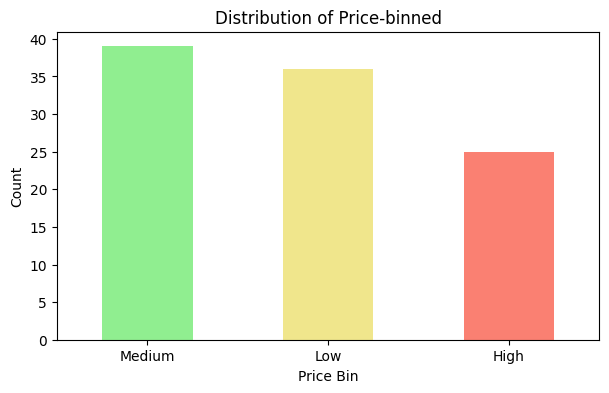

In [12]:
# Visualize the bin distribution
plt.figure(figsize=(7, 4))
df['Price-binned'].value_counts().plot(kind='bar', color=['lightgreen','khaki','salmon'])
plt.title('Distribution of Price-binned')
plt.xlabel('Price Bin')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Operation 5 — Convert Categorical Variable `Screen` into Quantitative Variables

`pd.get_dummies()` performs **one-hot encoding** — creates a separate 0/1 column for each unique category.

The original `Screen` column has 4 categories: `Full HD`, `IPS Panel`, `4K`, `Touchscreen`.
After encoding we get 4 new columns: `Screen_Full HD`, `Screen_IPS Panel`, `Screen_4K`, `Screen_Touchscreen`.

In [13]:
# Show original unique values
print("Unique Screen values:")
print(df['Screen'].unique())
print("\nValue counts:")
print(df['Screen'].value_counts())

Unique Screen values:
<StringArray>
['IPS Panel', 'Full HD', 'Touchscreen', '4K']
Length: 4, dtype: str

Value counts:
Screen
IPS Panel      30
Touchscreen    28
4K             24
Full HD        18
Name: count, dtype: int64


In [14]:
# Apply one-hot encoding to the 'Screen' column
df_encoded = pd.get_dummies(df, columns=['Screen'], drop_first=False)

# Find the new dummy columns
screen_cols = [c for c in df_encoded.columns if c.startswith('Screen_')]
print("New columns from one-hot encoding:")
for c in screen_cols:
    print(f"  - {c}")

# Display preview
print("\nPreview:")
df_encoded[screen_cols].head(10)

New columns from one-hot encoding:
  - Screen_Size_cm
  - Screen_Size_inches
  - Screen_4K
  - Screen_Full HD
  - Screen_IPS Panel
  - Screen_Touchscreen

Preview:


,Screen_Size_cm,Screen_Size_inches,Screen_4K,Screen_Full HD,Screen_IPS Panel,Screen_Touchscreen
0,38.10,15.0,False,False,True,False
1,43.94,17.3,False,True,False,False
2,43.94,17.3,False,False,False,True
3,33.78,13.3,False,False,False,True
4,38.10,15.0,True,False,False,False
5,39.62,15.6,False,True,False,False
6,35.56,14.0,False,False,False,True
7,35.56,14.0,False,False,False,True
8,33.78,13.3,True,False,False,False
9,33.78,13.3,False,False,True,False


In [15]:
# Convert True/False to integer 0/1 (cleaner for ML algorithms)
df_encoded[screen_cols] = df_encoded[screen_cols].astype(int)
df_encoded[screen_cols].head(10)

,Screen_Size_cm,Screen_Size_inches,Screen_4K,Screen_Full HD,Screen_IPS Panel,Screen_Touchscreen
0,38,15,0,0,1,0
1,43,17,0,1,0,0
2,43,17,0,0,0,1
3,33,13,0,0,0,1
4,38,15,1,0,0,0
5,39,15,0,1,0,0
6,35,14,0,0,0,1
7,35,14,0,0,0,1
8,33,13,1,0,0,0
9,33,13,0,0,1,0


## Step 3: Final Cleaned and Transformed DataFrame

In [16]:
# Replace df with the encoded version
df = df_encoded

print("Final shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Final shape: (100, 15)

All columns:
['Manufacturer', 'Category', 'Screen_Size_cm', 'CPU_Frequency_GHz', 'RAM_GB', 'Storage_GB', 'Weight_kg', 'Price', 'Screen_Size_inches', 'Weight_pounds', 'Price-binned', 'Screen_4K', 'Screen_Full HD', 'Screen_IPS Panel', 'Screen_Touchscreen']

Missing values: 0


,Manufacturer,Category,Screen_Size_cm,CPU_Frequency_GHz,RAM_GB,Storage_GB,Weight_kg,Price,Screen_Size_inches,Weight_pounds,Price-binned,Screen_4K,Screen_Full HD,Screen_IPS Panel,Screen_Touchscreen
0,Acer,Ultrabook,38,2.80,8,1024,1.830000,1722.22,15,4.03,Medium,0,0,1,0
1,Asus,Notebook,43,3.02,4,512,2.180000,1752.16,17,4.81,Medium,0,1,0,0
2,Apple,Gaming,43,2.23,32,512,1.070000,2407.94,17,2.36,High,0,0,0,1
3,HP,Workstation,33,2.68,8,256,2.223838,1149.66,13,4.90,Low,0,0,0,1
4,HP,Ultrabook,38,2.98,16,128,2.710000,1601.15,15,5.97,Medium,1,0,0,0


## Conclusion

We performed five data-wrangling operations on `laptops.csv`:

1. **Missing value imputation** — replaced NaN in numeric columns with the column **mean** using `fillna()`.
2. **Type conversion** — used `pd.to_numeric(errors='coerce')` to ensure `Weight_kg` and `Screen_Size_cm` are proper numeric (`float64`) types.
3. **Unit standardization** — converted screen size from **cm → inches** (÷ 2.54) and weight from **kg → pounds** (× 2.20462), creating two new columns.
4. **Binning** — used `pd.cut(bins=3, labels=['Low','Medium','High'])` to discretize continuous `Price` into 3 categories. Stored as new column `Price-binned`.
5. **One-hot encoding** — used `pd.get_dummies(columns=['Screen'])` to convert the categorical `Screen` column into 4 binary 0/1 columns, making it usable by ML models.

The final DataFrame is fully numeric, has standardized units, and is ready for any downstream task — visualization, statistical analysis, or machine learning.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, type conversion, `fillna`, `cut`, `get_dummies` |
| **numpy** | Numerical operations |
| **matplotlib** | Bar plot for binned price distribution |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV into DataFrame
- `df.shape` — `(rows, columns)`
- `df.head(n)` — first n rows
- `df.info()` — column names, dtypes, null counts
- `df.describe()` — summary statistics
- `df.dtypes` — data types of each column

#### Missing Value Handling
- `df.isnull()` — boolean DataFrame; True where NaN
- `.sum()` — counts True values
- `df['col'].fillna(value)` — replace NaN with a value
- `df['col'].mean()` — average of column
- `df.select_dtypes(include='number')` — pick only numeric columns

#### Type Conversion
- `pd.to_numeric(col, errors='coerce')` — convert column to numeric; non-convertible values become NaN
- `.astype(int)` — convert dtype to integer

#### Unit Conversion
- Division `df['col'] / 2.54` — broadcast division across all rows
- Multiplication `df['col'] * 2.20462` — broadcast multiplication
- `.round(2)` — round to 2 decimal places

#### Binning
- `pd.cut(values, bins=3, labels=[...])` — divides values into N equal-width bins, optionally labeled
- `.value_counts()` — count occurrences of each bin

#### Categorical Encoding
- `pd.get_dummies(df, columns=['col'])` — one-hot encode specified columns
- `drop_first=False` — keep all dummy columns (`drop_first=True` removes the first to avoid multicollinearity)

#### Visualization
- `series.plot(kind='bar')` — bar plot directly from a Series
- `plt.xticks(rotation=0)` — keep x-axis labels horizontal

### Key Concepts

#### Mean vs Median Imputation
- **Mean** — sensitive to outliers; only safe when distribution is roughly symmetric.
- **Median** — robust to outliers; safer default choice.

This assignment specifically asks for **mean** imputation.

#### Data Type Coercion (`errors='coerce'`)
When a numeric column is loaded as `object` (string) due to typos or stray characters, `pd.to_numeric` would normally fail. Setting `errors='coerce'` converts what it can and turns the rest into NaN — which we can then impute.

#### Unit Conversion Constants
- **1 inch = 2.54 cm**, so `inches = cm / 2.54`
- **1 kg ≈ 2.20462 lbs**, so `pounds = kg × 2.20462`

#### Binning (`pd.cut` vs `pd.qcut`)
- **`pd.cut(bins=3)`** — divides the *range* into 3 equal-width intervals. Bin sizes can be uneven if the data is skewed.
- **`pd.qcut(q=3)`** — divides the *count* into 3 equal-frequency groups (each bin has roughly the same number of rows).

We use `pd.cut` because the question asks for 3 bins of equal price ranges (Low / Medium / High).

#### One-Hot Encoding
Converts each category into a separate binary column. Required because:
- ML algorithms can't process strings directly
- Treating categories as numbers (e.g., 1, 2, 3) implies an order that doesn't exist
- One-hot encoding treats categories as truly separate

#### `drop_first` Parameter
- `drop_first=True` removes one dummy column to avoid the **dummy variable trap** (perfect multicollinearity). Use this for regression models.
- `drop_first=False` keeps all columns. Easier to read; safe for tree-based models or descriptive analysis.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is data wrangling?**
The process of cleaning and preparing raw data for analysis — handling missing values, type conversions, unit standardization, binning, and encoding categorical features.

**Q2. Why use mean imputation instead of median?**
Mean is the default for symmetric, outlier-free numeric data. It uses *all* values when computing the replacement. Median is preferred only when outliers exist.

**Q3. When does mean imputation fail?**
When the data is highly skewed or has extreme outliers — the mean is dragged toward extreme values, distorting the imputation.

**Q4. What is data type conversion and why is it needed?**
Pandas may load a column as `object` (string) if even one cell has a stray character or unexpected value. ML algorithms require numeric types, so we use `pd.to_numeric()` to force the conversion.

**Q5. What does `errors='coerce'` do?**
Converts what it can to numeric; turns the rest into NaN instead of raising an error. Lets us catch and impute problematic values.

### Unit Conversion

**Q6. Conversion: cm to inches?**
inches = cm ÷ 2.54

**Q7. Conversion: kg to pounds?**
pounds = kg × 2.20462

**Q8. Why standardize units?**
Different countries use different measurement systems. Standardizing to a common unit (especially industry-standard like inches for screens) makes data comparable.

### Binning

**Q9. What is binning?**
Converting a continuous variable into a small number of ordered categories (bins).

**Q10. Why bin a continuous variable?**
- Simplifies analysis (Low / Medium / High vs hundreds of distinct prices)
- Creates ordinal targets for classification
- Reduces the impact of outliers
- Makes patterns more interpretable

**Q11. Difference between `pd.cut` and `pd.qcut`?**
- **`pd.cut`** — equal-width bins (range divided evenly)
- **`pd.qcut`** — equal-frequency bins (each bin contains the same number of rows)

**Q12. Which is better for skewed data?**
`pd.qcut`, because `pd.cut` would produce empty or almost-empty bins for the long tail.

**Q13. What if the data is heavily right-skewed and you use `pd.cut`?**
Most rows fall into the "Low" bin; "High" bin may have very few rows.

### Encoding

**Q14. What is one-hot encoding?**
Converting each category in a column into a separate 0/1 column. Lets ML algorithms process categorical data.

**Q15. Why not just label-encode (assign 0, 1, 2, ...)?**
Label encoding implies an **order** between categories. ML algorithms might think "category 2 > category 1" — which is wrong for unordered (nominal) categories like colors or screen types.

**Q16. What is the dummy variable trap?**
When all dummy columns sum to 1, they're perfectly correlated. This causes multicollinearity in linear models. Solved by dropping one column with `drop_first=True`.

**Q17. When to use `drop_first=False`?**
For tree-based models (Random Forest, XGBoost) and descriptive analysis where multicollinearity isn't a concern.

### Practical / Code

**Q18. What does `df.select_dtypes(include='number')` return?**
A DataFrame with only the numeric columns. Useful when applying numeric-only operations (mean, sum, etc.) on a mixed-type DataFrame.

**Q19. What's the difference between `fillna()` and `dropna()`?**
- `fillna(value)` — replace NaN with a value
- `dropna()` — remove rows containing NaN

**Q20. Why use `.round(2)` after unit conversion?**
To make values cleaner and easier to read (e.g., 33.78 instead of 33.78215...).

**Q21. Why `astype(int)` after `get_dummies`?**
By default `get_dummies` returns booleans (True/False) in newer pandas versions. Converting to integers (0/1) is cleaner for ML models and downstream code.